In [1]:
!pip install -q protobuf==3.20.3
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, bu

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-passengers/AirPassengers.csv


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/kaggle/input/air-passengers/AirPassengers.csv')
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
df['Month'] = pd.to_datetime(df['Month'])
print(df['Month'].dtypes)

datetime64[ns]


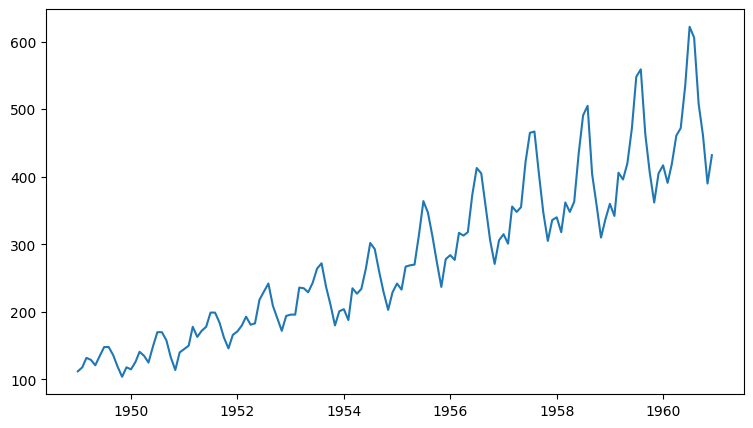

In [7]:
## plot the data
plt.figure(figsize = (9,5))
plt.plot(df['Month'], df['#Passengers'])
plt.show()

In [8]:
# First we will scale or dataset. 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['#Passengers']])

In [9]:
scaled_data[:5]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

# Conver the data into a list
timeseries_data = df['#Passengers'].to_list()
timeseries_data[:10]

In [10]:
# preparing independent and dependent features
def prepare_data(time_series_data, n_features):
    X,y = [],[]
    for i in range(len(time_series_data)):
        # find the end of this pattern
        end_ix = i + n_features
        # check if we are beyond the sequence
        if end_ix > len(time_series_data)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = time_series_data[i:end_ix], time_series_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    return np.array(X), np.array(y)

In [11]:
# As there was yearly seasonality in the dataset so will take n_steps = 12
n_steps = 12

# split into samples
X, y = prepare_data(scaled_data, n_steps)

In [12]:
X[:1]

array([[[0.01544402],
        [0.02702703],
        [0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02702703]]])

In [13]:
y[:1]

array([[0.02123552]])

In [14]:
X.shape

(132, 12, 1)

In [15]:
# Reshape for LSTM: [samples, time_steps, features]
n_features = 1
X = X.reshape(X.shape[0], X.shape[1], n_features)

In [16]:
X.shape

(132, 12, 1)

In [17]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Building LSTM Model

In [18]:
#Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten

2025-12-20 14:55:31.546810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766242532.158822      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766242532.311043      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [19]:
model = Sequential()
model.add(LSTM(50, activation= 'tanh', input_shape = (n_steps, n_features)))
model.add(Dense(1))

model.compile(optimizer='adam',loss = 'mse')
history = model.fit(X_train, y_train, epochs = 50, batch_size = 16, 
                    validation_data = (X_test,y_test))

2025-12-20 14:55:57.132605: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.1518 - val_loss: 0.0615
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0560 - val_loss: 0.0107
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0130 - val_loss: 0.0178
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0205 - val_loss: 0.0093
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0129 - val_loss: 0.0104
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0141 - val_loss: 0.0084
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0101 - val_loss: 0.0075
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096 - val_loss: 0.0070
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0121 - val_loss: 0.0071
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0092 - val_loss: 0.0067
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0093 - val_loss: 0.0063
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0115 - val_loss: 0.0059
E

## Model Evaluation

In [20]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


In [21]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

0.06515731130547568

## Inverse Scaling

In [22]:
predicted = scaler.inverse_transform(y_pred)
actual = scaler.inverse_transform(y_test)

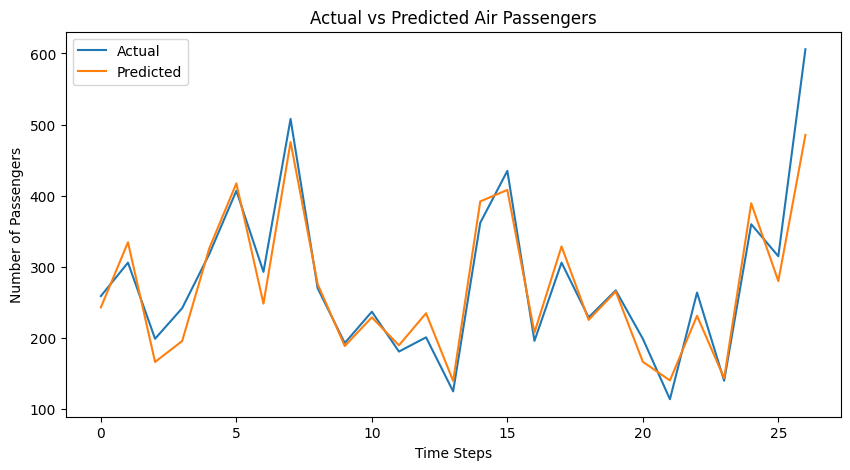

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(actual, label='Actual')
plt.plot(predicted, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Number of Passengers')
plt.title('Actual vs Predicted Air Passengers')
plt.legend()
plt.show()

## Predict the next 24 months using our trained LSTM model

In [24]:
# Prepare the Last Input Window
last_sequence = scaled_data[-n_steps:]
last_sequence

array([[0.6042471 ],
       [0.55405405],
       [0.60810811],
       [0.68918919],
       [0.71042471],
       [0.83204633],
       [1.        ],
       [0.96911197],
       [0.77992278],
       [0.68918919],
       [0.55212355],
       [0.63320463]])

In [25]:
# Recursive Forecasting Loop (24 Months)

future_steps = 24
future_predictions = []

current_sequence = last_sequence.copy()

for i in range(future_steps):
    # reshape for LSTM: (1, timesteps, features)
    input_seq = current_sequence.reshape(1,n_steps,1)
    
    # predict next month
    next_pred = model.predict(input_seq, verbose = 0)

    # store prediction
    future_predictions.append(next_pred[0,0])
    
    # update sequence (slide window)
    current_sequence = np.append(
        current_sequence[1:], next_pred, axis = 0)
    

In [26]:
len(future_predictions)

24

In [27]:
# Inverse Transform to Original Passenger Scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_inv = scaler.inverse_transform(future_predictions)

In [28]:
# Create Timeline for Future Months

last_date = df['Month'].iloc[-1]
future_dates = pd.date_range(start = last_date + pd.DateOffset(months=1),
                             periods = 24,
                             freq = 'ME')

future_df = pd.DataFrame({'Month': future_dates, 
                          'Predicted_Passengers': future_predictions_inv.flatten()})

In [29]:
future_df.head()

,Month,Predicted_Passengers
0,1961-01-31,467.146790
1,1961-02-28,476.870209
2,1961-03-31,489.346924
3,1961-04-30,500.251984
4,1961-05-31,507.342285


## Plot Historical + Future Forecast

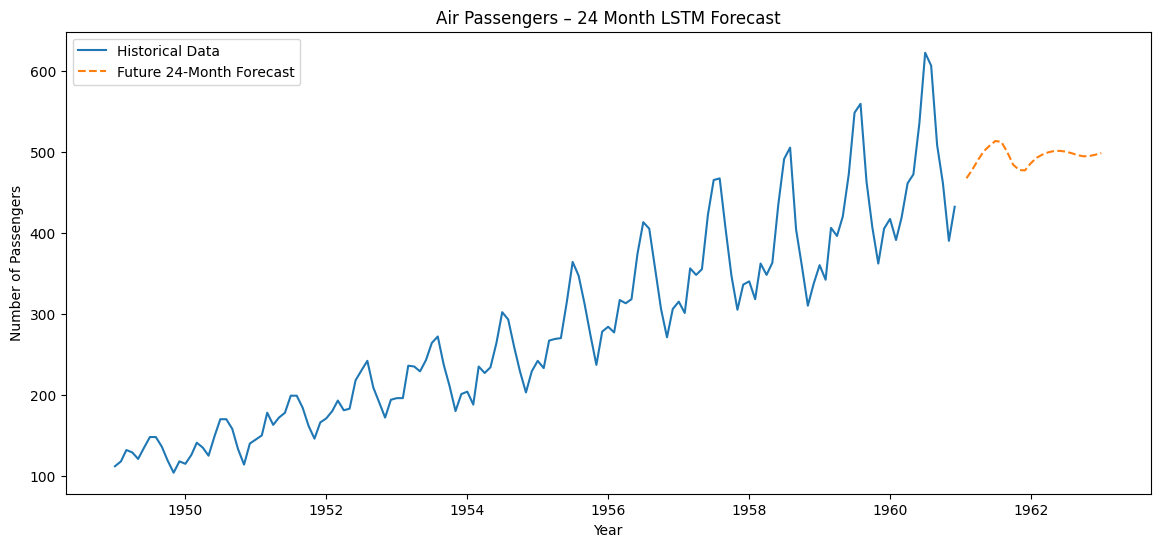

In [30]:
plt.figure(figsize=(14,6))

# historical data
plt.plot(df['Month'], df['#Passengers'], label = 'Historical Data')
# future forecast
plt.plot(future_df['Month'], future_df['Predicted_Passengers'],
         label = 'Future 24-Month Forecast', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers – 24 Month LSTM Forecast')
plt.legend()
plt.show()